# Open WOD CTD dataset

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import gsw
import pyresample as pr
from pathlib import Path
from os.path import join,expanduser
import sys

# identify user's home directory
user_home_dir = expanduser('~/github_others')

# import the ECCOv4 py library 
sys.path.insert(0,join(user_home_dir,'ECCOv4-py'))
import ecco_v4_py as ecco

### Plot vars

In [3]:
ctd_ds = xr.open_mfdataset('/Users/mzahn/data/McFLURRIE/WOD/standard_depths/CTD/*.nc')

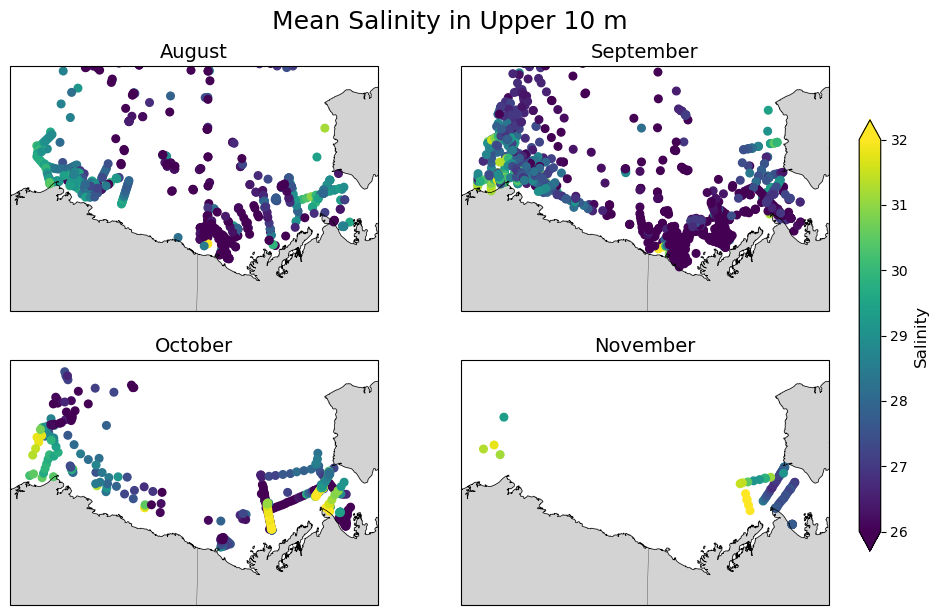

In [4]:
# months you want to plot
months = [8, 9, 10, 11]
month_names = {8: "August", 9: "September", 10: "October", 11: "November"}

# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, axes = plt.subplots(2, 2, figsize=(13, 7),
                         subplot_kw={'projection': proj})

axes = axes.flatten()

# keep reference to last scatter for colorbar
sc = None

for ax, month in zip(axes, months):

    # set map extent
    ax.set_extent([-157.5, -125, 67, 75.5], crs=ccrs.PlateCarree())

    # add isobaths
    # bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

    # add map features
    ax.add_feature(cfeature.LAND, color='lightgray')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)

    # gridlines (no labels)
    # gl = ax.gridlines(draw_labels=False, dms=True,
    #                   x_inline=False, y_inline=False)

    # subset each dataset by month
    apb_m = ctd_ds.where(ctd_ds.time.dt.month == month, drop=True)

    # SCATTER PLOTS (capturing the last one for colorbar)
    sc = ax.scatter(
        apb_m.lon, apb_m.lat, s=30,
        c=apb_m.Salinity.sel(z=slice(0,10)).mean('z'),
        vmin=26, vmax=32, transform=ccrs.PlateCarree()
    )

    # panel title
    ax.set_title(f"{month_names[month]}", fontsize=14)
    
fig.suptitle("Mean Salinity in Upper 10 m          ", fontsize=18, y=0.96)

cbar = fig.colorbar(sc, ax=axes, location='right', shrink=0.8, pad=0.03, extend='both')
cbar.set_label("Salinity", fontsize=12)

# spacing
# plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()

### Collocate CTD profiles and ECCO profiles

#### Open ECCO data

In [7]:
# --- Directory containing ECCO .data files
data_dir = Path("/Users/mzahn/data/ECCO/ECCO_V4r6/SALT_mon_mean")

# --- List and sort all .data files
files = sorted(data_dir.glob("*.data"))
print(f"Found {len(files)} .data files")

Found 396 .data files


In [9]:
# create monthly time coordinate (15th of each month from Jan 1992 to Dec 2024)
time_coord = pd.date_range("1992-01-01", "2024-12-01", freq="MS") + pd.Timedelta(days=14)

# sanity check
if len(files) != len(time_coord):
    print(f"Warning: {len(files)} files but {len(time_coord)} time steps!")

In [11]:
# load all files into xarray DataArrays
arrays = []
for i, filepath in enumerate(files):

    array = ecco.read_llc_to_tiles(
        str(filepath.parent),
        filepath.name, llc=90, nk=50,
        less_output=True
    )

    ds = ecco.llc_tiles_to_xda(
        array,
        var_type="c",
        dim4="depth",
        dim5="time"
    )
    ds = ds.expand_dims("time")
    
    # Assign a single mid-month time coordinate
    ds = ds.assign_coords(time=[time_coord[i]])

    arrays.append(ds)

# --- Combine all DataArrays into one along the time dimension
combined = xr.concat(arrays, dim="time")

# print(combined)

In [12]:
# Open ECCO grid
ecco_grid = xr.open_dataset('~/data/grids/GRID_GEOMETRY_ECCO_V4r4_native_llc0090.nc')

In [13]:
salt_ds = combined.where(ecco_grid.maskC)

#### Select salinity profiles that are valid

In [14]:
# filter out profiles where S profile was flagged (bad)
ctd_ds = ctd_ds.where((ctd_ds.Salinity_WODprofileflag==0).compute(),drop=True)

#### Collocate

In [18]:
salt_surf = salt_ds.isel(k=0,tile=slice(6,8))

In [19]:
# Convert CTD times to pandas for easy handling
ctd_time = pd.to_datetime(ctd_ds.time.values)

# Create corresponding model monthly timestamps (mid-month)
model_month_time = (
    ctd_time.to_period("M")
    .to_timestamp("M")            # end of month
    - pd.Timedelta(days=14)       # shift to ~15th
)

# Ensure these times exist in the model time coordinate
model_time_index = pd.to_datetime(salt_surf.time.values)

# Find nearest model time for each CTD profile
matched_model_time = xr.DataArray(
    model_time_index[
        np.abs(model_time_index.values[:, None] - model_month_time.values).argmin(axis=0)
    ],
    dims="time",
    coords={"time": ctd_ds.time}
)

In [44]:
# --- MODEL GRID (2-D, static) ---
model_lon = salt_surf['XC'].values
model_lat = salt_surf['YC'].values

model_swath = pr.geometry.SwathDefinition(
    lons=model_lon.ravel(),
    lats=model_lat.ravel()
)

# --- CTD OBS LOCATIONS (1-D) ---
obs_lon = ctd_ds['lon'].values
obs_lat = ctd_ds['lat'].values
obs_swath = pr.geometry.SwathDefinition(
    lons=obs_lon,
    lats=obs_lat
)

# --- NEAREST NEIGHBOR SEARCH (spatial only) ---
idx, dist, idx_valid, dist_valid = pr.kd_tree.get_neighbour_info(
    source_geo_def=model_swath,
    target_geo_def=obs_swath,
    radius_of_influence=5e4,  # 50 km
    neighbours=1
)

In [62]:
model_values = np.full(ctd_ds.dims["time"], np.nan)
XC_values = np.full(ctd_ds.dims["time"], np.nan)
YC_values = np.full(ctd_ds.dims["time"], np.nan)

for i, tmod in enumerate(matched_model_time.values):
    # Select the monthly model slice
    model_slice = salt_surf.sel(time=tmod)

    # Flatten spatial field
    model_data_flat = model_slice.values.ravel()
    XC_data_flat = model_slice.XC.values.ravel()
    YC_data_flat = model_slice.YC.values.ravel()

    # Extract collocated value
    if i < len(idx_valid):
        model_values[i] = model_data_flat[idx_valid[i]]
        XC_values[i] = XC_data_flat[idx_valid[i]]
        YC_values[i] = YC_data_flat[idx_valid[i]]

/tmp/ipykernel_8762/1511255020.py:1: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  model_values = np.full(ctd_ds.dims["time"], np.nan)
/tmp/ipykernel_8762/1511255020.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  XC_values = np.full(ctd_ds.dims["time"], np.nan)
/tmp/ipykernel_8762/1511255020.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  YC_values = np.full(ctd_ds.dims["time"], np.

In [118]:
model_at_ctd = xr.DataArray(
    model_values,
    dims="time",
    coords={
        "time": matched_model_time.values,
        "XC": ("time", XC_values),
        "YC": ("time", YC_values),
    },
    name="model_salinity_at_ctd",
    attrs={
        "description": "Monthly mean model salinity collocated to CTD profiles",
        "spatial_radius_km": 50,
    },
)

In [120]:
# calculate mean salinity in upper 10 m for in situ profiles
ctd_salt_10m_avg = ctd_ds.Salinity.sel(z=slice(0,10)).mean(dim=['z'])

In [122]:
print(ctd_salt_10m_avg.isel(time=0).time.values)
print(ctd_salt_10m_avg.isel(time=0).lat.values)
print(ctd_salt_10m_avg.isel(time=0).lon.values)
print(ctd_salt_10m_avg.isel(time=0).values)

1992-04-01T21:25:59.995078656
71.4335
-137.9122
30.85343102243794


In [128]:
print(model_at_ctd.isel(time=0).time.values)
print(model_at_ctd.isel(time=0).YC.values)
print(model_at_ctd.isel(time=0).XC.values)
print(model_at_ctd.isel(time=0).values)

1992-04-15T00:00:00.000000000
71.39543914794922
-138.5645294189453
31.6584529876709


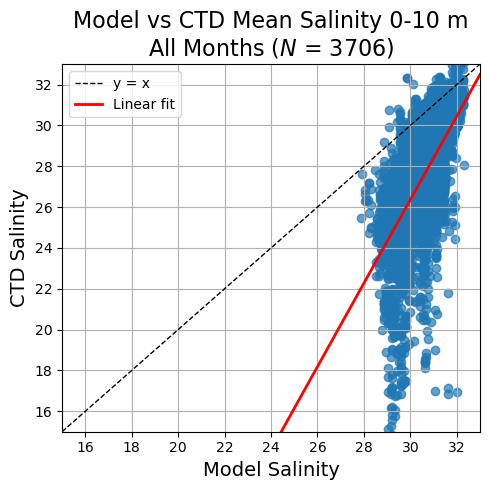

In [141]:
import numpy as np
import matplotlib.pyplot as plt

# Flatten and remove NaNs
x = np.ravel(model_at_ctd)
y = np.ravel(ctd_salt_10m_avg)
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

# Scatter plot
plt.figure(figsize=(5,5))
plt.scatter(x, y, marker='o', alpha=0.7)

# 1:1 line
xymin = 15
xymax = 33
plt.plot([xymin, xymax], [xymin, xymax], 'k--', linewidth=1, label='y = x')

# Linear fit
slope, intercept = np.polyfit(x, y, 1)
fit_line = slope * np.array([xymin, xymax]) + intercept
plt.plot([xymin, xymax], fit_line, 'r-', linewidth=2, label=f'Linear fit')

# Labels and title
plt.xlabel("Model Salinity", fontsize=14)
plt.ylabel("CTD Salinity", fontsize=14)
plt.title(f"Model vs CTD Mean Salinity 0-10 m\nAll Months ($N$ = {len(model_at_ctd.time)})", fontsize=16)

plt.xlim(xymin, xymax)
plt.ylim(xymin, xymax)
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig('/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/ctd_model_comparison_scatter_plot.png',
#             dpi=300, bbox_inches='tight')

plt.show()

In [334]:
# Flatten and remove NaNs (you already have this)
x = np.ravel(model_at_ctd)
y = np.ravel(ctd_salt_10m_avg)
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

# Calculate RMSD
rmsd = np.sqrt(np.mean((x - y)**2))
print(f"RMSD: {rmsd:.3f} PSU")

RMSD: 4.011 PSU


#### Plot only fall months

In [332]:
model_at_ctd

<xarray.DataArray 'model_salinity_at_ctd' (time: 3706)> Size: 30kB
array([31.65845299, 31.78782654, 31.8055706 , ..., 31.42352486,
       31.42248535, 31.40766335])
Coordinates:
  * time     (time) datetime64[ns] 30kB 1992-04-15 1992-04-15 ... 2018-11-15
    XC       (time) float64 30kB -138.6 -137.2 -136.2 ... -159.5 -158.5 -159.8
    YC       (time) float64 30kB 71.4 70.72 70.54 70.54 ... 72.32 71.84 71.91
Attributes:
    description:        Monthly mean model salinity collocated to CTD profiles
    spatial_radius_km:  50

In [143]:
model_at_ctd_fall = model_at_ctd.sel(time=model_at_ctd.time.dt.month.isin([9, 10, 11]))
ctd_salt_10m_avg_fall = ctd_salt_10m_avg.sel(time=ctd_salt_10m_avg.time.dt.month.isin([9, 10, 11]))

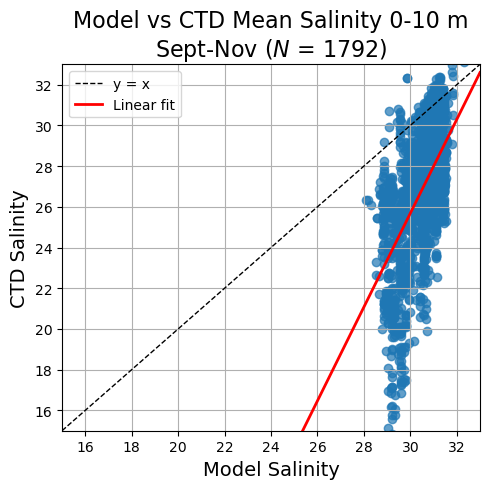

In [147]:
import numpy as np
import matplotlib.pyplot as plt

# Flatten and remove NaNs
x = np.ravel(model_at_ctd_fall)
y = np.ravel(ctd_salt_10m_avg_fall)
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

# Scatter plot
plt.figure(figsize=(5,5))
plt.scatter(x, y, marker='o', alpha=0.7)

# 1:1 line
xymin = 15
xymax = 33
plt.plot([xymin, xymax], [xymin, xymax], 'k--', linewidth=1, label='y = x')

# Linear fit
slope, intercept = np.polyfit(x, y, 1)
fit_line = slope * np.array([xymin, xymax]) + intercept
plt.plot([xymin, xymax], fit_line, 'r-', linewidth=2, label=f'Linear fit')

# Labels and title
plt.xlabel("Model Salinity", fontsize=14)
plt.ylabel("CTD Salinity", fontsize=14)
plt.title(f"Model vs CTD Mean Salinity 0-10 m\nSept-Nov ($N$ = {len(model_at_ctd_fall.time)})", fontsize=16)

plt.xlim(xymin, xymax)
plt.ylim(xymin, xymax)
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig('/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/ctd_model_comparison_scatter_plot.png',
#             dpi=300, bbox_inches='tight')

plt.show()

In [336]:
# Flatten and remove NaNs (you already have this)
x = np.ravel(model_at_ctd_fall)
y = np.ravel(ctd_salt_10m_avg_fall)
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

# Calculate RMSD
rmsd = np.sqrt(np.mean((x - y)**2))
print(f"RMSD: {rmsd:.3f} PSU")

RMSD: 4.719 PSU


### Plot maps

#### Open sea ice data

In [284]:
# --- Directory containing ECCO .data files
data_dir = Path("/Users/mzahn/data/ECCO/ECCO_V4r6/SIarea_mon_mean")

# --- List and sort all .data files
files = sorted(data_dir.glob("*.data"))
print(f"Found {len(files)} .data files")

Found 396 .data files


In [286]:
# create monthly time coordinate (15th of each month from Jan 1992 to Dec 2024)
time_coord = pd.date_range("1992-01-01", "2024-12-01", freq="MS") + pd.Timedelta(days=14)

# sanity check
if len(files) != len(time_coord):
    print(f"Warning: {len(files)} files but {len(time_coord)} time steps!")

In [288]:
# load all files into xarray DataArrays
arrays = []
for i, filepath in enumerate(files):

    array = ecco.read_llc_to_tiles(
        str(filepath.parent),
        filepath.name, llc=90, nk=1,
        less_output=True
    )

    ds = ecco.llc_tiles_to_xda(
        array,
        var_type="c",
        dim4="depth",
        dim5="time"
    )
    ds = ds.expand_dims("time")
    
    # Assign a single mid-month time coordinate
    ds = ds.assign_coords(time=[time_coord[i]])

    arrays.append(ds)

# --- Combine all DataArrays into one along the time dimension
combined = xr.concat(arrays, dim="time")

In [290]:
sic_ds = combined.where(ecco_grid.maskC.isel(k=0))

In [322]:
date_select = '2016-09'

In [324]:
ctd_tmp = ctd_ds.sel(time=date_select).Salinity.sel(z=slice(0,10)).mean("z")

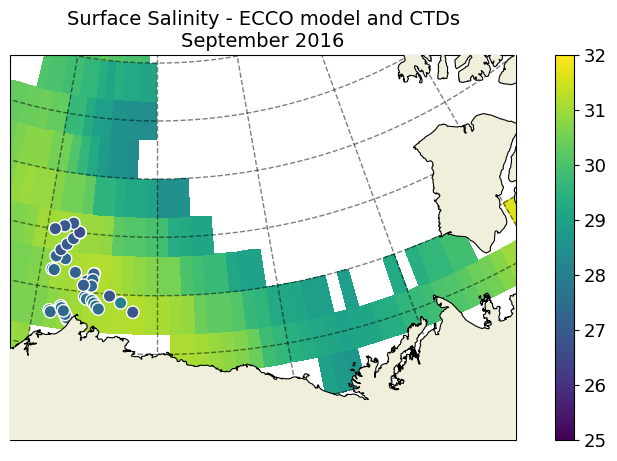

In [326]:
plt.figure(figsize=(10,5))
plt.rcParams['font.size'] = 13

sic_tmp = sic_ds.sel(time=date_select)
tmp_plt = salt_ds.isel(k=0).sel(time=date_select).where(sic_tmp<0.15)

# Create the plot with ECCO’s helper function
f, ax, p, cbar, lon_c, lat_c, data_latlon, gl = ecco.plot_proj_to_latlon_grid(
    ecco_grid.XC, ecco_grid.YC,
    tmp_plt,
    projection_type='stereo',
    plot_type='pcolormesh',
    show_colorbar=True,
    dx=1, dy=1,
    cmin=25, cmax=32,
    lat_lim=60,
    user_lon_0=-150
)
p.set_zorder(1)
# zoom into the Beaufort Sea (approx bounds)
ax.set_extent([-160, -125, 68, 77], crs=ccrs.PlateCarree())

ax.scatter(
    ctd_tmp.lon, ctd_tmp.lat,
    c=ctd_tmp.values,vmin=25,vmax=32,
    cmap='viridis',edgecolor='white',
    s=80,zorder=6,
    transform=ccrs.PlateCarree()
)

plt.title("Surface Salinity - ECCO model and CTDs\nSeptember 2016", fontsize=14)
plt.show();

#### Plot monthly mean from SMAP

In [206]:
smap_ds = xr.open_mfdataset('/Users/mzahn/data/satellite_sss/smap_v6/*.nc',combine='by_coords')

In [207]:
# Resample to get monthly means (mean for each calendar month in the time series)
smap_mon_avg = smap_ds['sss_smap'].resample(time='ME').mean()

In [328]:
smap_mon = smap_mon_avg.sel(time=date_select)

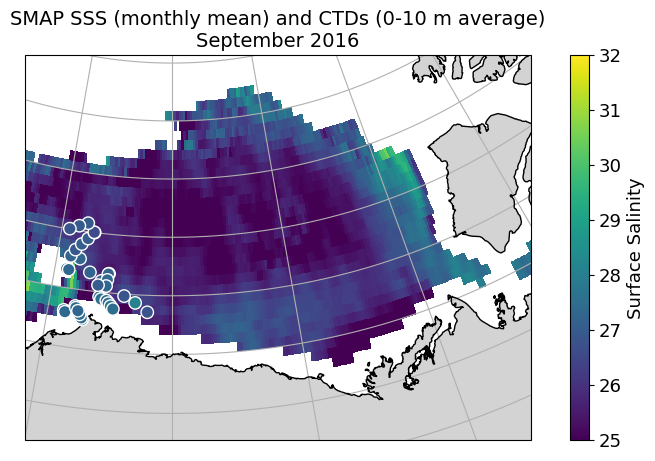

In [330]:
# Create figure and stereographic projection
fig = plt.figure(figsize=(10,5))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-150))
plt.rcParams['font.size'] = 13

# Plot the gridded data with pcolormesh
# Convert lon/lat to 2D meshgrid if needed
lon = smap_mon['lon'].values
lat = smap_mon['lat'].values
data = smap_mon.isel(time=0).values

# Plot pcolormesh
pc = ax.pcolormesh(
    lon, lat, data,
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    vmin=25, vmax=32,
    zorder=1
)

# Add scatter points on top
ax.scatter(
    ctd_tmp.lon, ctd_tmp.lat,
    c=ctd_tmp.values,
    cmap='viridis',
    vmin=25, vmax=32,
    edgecolor='white',
    s=80,
    zorder=6,
    transform=ccrs.PlateCarree()
)

# Zoom into Beaufort Sea
ax.set_extent([-160, -125, 68, 77], crs=ccrs.PlateCarree())

# Add gridlines, coastlines, and land for context
ax.add_feature(cfeature.LAND, zorder=2, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, zorder=3)
ax.gridlines(draw_labels=False)

# Add colorbar
cbar = plt.colorbar(pc, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label('Surface Salinity')

plt.title("SMAP SSS (monthly mean) and CTDs (0-10 m average)\nSeptember 2016", fontsize=14)
plt.show()